# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

In [2]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("./album_sales.csv")
df.head()

,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

C:\Users\ellie\AppData\Local\Temp\ipykernel_31356\1076244845.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


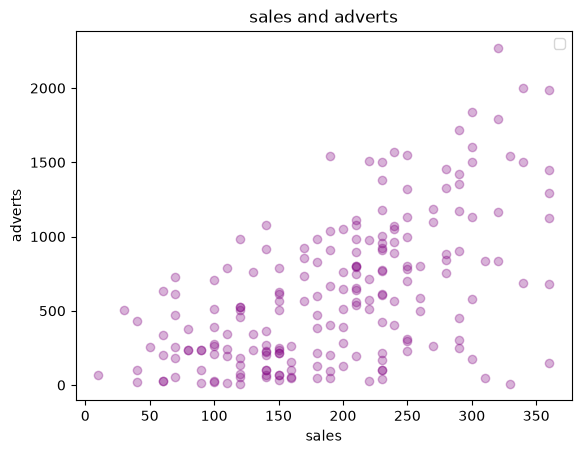

C:\Users\ellie\AppData\Local\Temp\ipykernel_31356\1076244845.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


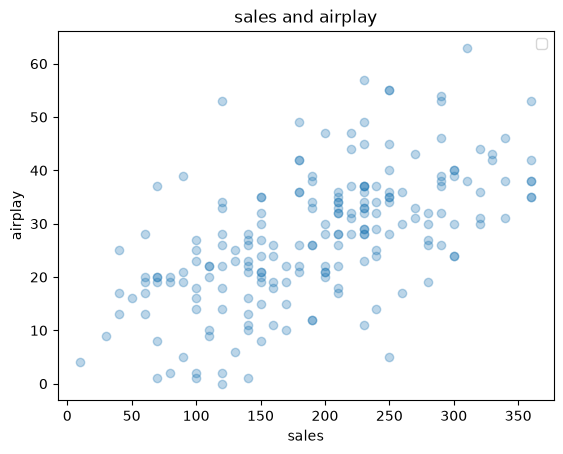

C:\Users\ellie\AppData\Local\Temp\ipykernel_31356\1076244845.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


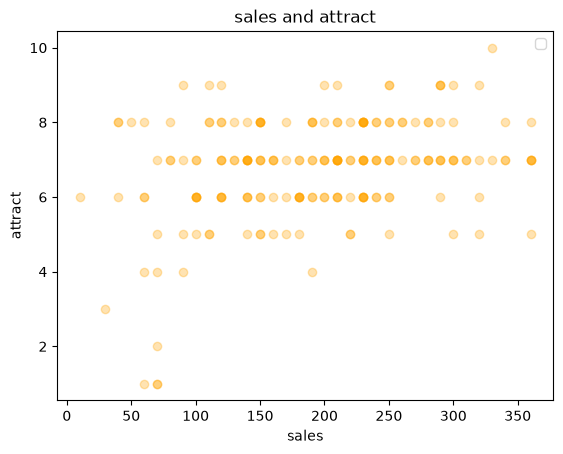

In [3]:
# sales and adverts
plt.scatter(x=df['sales'], y = df['adverts'], alpha=0.3, color='purple')
plt.xlabel('sales')
plt.ylabel('adverts')
plt.title('sales and adverts')
plt.legend()
plt.show()

#sales and airplay
plt.scatter(x=df['sales'], y = df['airplay'], alpha=0.3)
plt.xlabel('sales')
plt.ylabel('airplay')
plt.title('sales and airplay')
plt.legend()
plt.show()

#sales and attract
plt.scatter(x=df['sales'], y = df['attract'], alpha=0.3, color='orange')
plt.xlabel('sales')
plt.ylabel('attract')
plt.title('sales and attract')
plt.legend()
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

In the scatter plots above the one with the strongest relationship was the sales and airplay. They had a positive relationship, and it was quite noticeable. The scatter plot with the weakest relationship was the sales and attract, which was basically a straight line. This means there wasn't really a trend between the two variables. Sales and adverts had a decent relationship, which was also positive, but not as strong as sales and airplay. 

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [5]:
# Code here
x = df['sales']
y = df['adverts']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                adverts   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        14:57:30   Log-Likelihood:                -1479.6
No. Observations:                 200   AIC:                             2963.
Df Residuals:                     198   BIC:                             2970.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -58.1948     73.016     -0.797      0.4

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-Statistic for this regression result show that the model is very significant. This is good, because it means that the variables are related, and this model is important.

The P-value is very low as well, having a value of 0.000. This is good because it means it is very unlikely these results happened on accident.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [22]:
z = 135000
x = z/1000
y = 134.1399 + (0.0961 * x)

print(f"A budget of {z} would get you {y} sales")


A budget of 135000 would get you 147.1134 sales


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [ ]:
x = df[['adverts', 'airplay', 'attract']]
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x) 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        15:06:19   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

The model 2, the multiple regression model, is better than the model 1, it has a higher R squared value, and it has a low P value as well. 

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name